In [9]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
from matplotlib import pyplot as plt

import sys
sys.path.append('..')
from basicfunc import MouseAnatomyTree, bootstrap_stat_test
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score, mutual_info_score
import scipy

import warnings
warnings.filterwarnings("ignore")


In [2]:
den_type = 'apical'
pyr23_only = True

In [3]:
used_morpho_features = ['Number of Bifurcations', 'Total Length']
mapped_cols = ['Bifur Num','Total Length']

feat_mapping_dict = dict(zip(used_morpho_features,mapped_cols))

homo_color_lut = {
                 'FL':np.array([255,206,72])/255.0,
                 'PL':np.array([153,217,234])/255.0,
                 'TL':np.array([118,137,211])/255.0}

# mouse
color1 = np.array([29/255,140/255,67/255])
# human
color2 = np.array([255,102,102])/255.0
# reference dataset
color3=np.array([191,200,215])/255.0

In [ ]:
mouse_anatomy_tree = MouseAnatomyTree('../Data/external/tree.json')

# cell type
df_ct_mouse = pd.read_csv(r'..\Data\metadata\mouse_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
else:
    df_ct_mouse = df_ct_mouse[df_ct_mouse['layer'].isin(['2/3', '5'])]
    df_ct_mouse = df_ct_mouse[df_ct_mouse['is_pyramidal']==1]
    
    pass

df_ct_human = pd.read_csv(r'..\Data\metadata\human_celltype.csv',index_col=0)
if pyr23_only:
    df_ct_human = df_ct_human[df_ct_human['layer'].isin(['L2/3'])]
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
else:
    df_ct_human = df_ct_human[df_ct_human['is_pyramidal']==1]
    pass


print("human", df_ct_human['homologous'].value_counts())
print("mouse", df_ct_mouse['homologous'].value_counts())


# morphology features of cropped swc
crop_thres_list = [50,]
restem = 8
path_morpho = r'E:\ZhixiYun\Projects\fMOST_atlas\Tables\Feature\Morphology'
path_nbranch = r'E:\ZhixiYun\Projects\fMOST_atlas\Tables\Feature\N_Branch'

dict_df_morpho_mouse = {}
for crop_thres in crop_thres_list:
    tmpdf = pd.read_csv(os.path.join(path_morpho, f"mouse_{den_type}_morphology_restem{restem}_magnify_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    tmpdf.columns = [feat_mapping_dict[x] for x in tmpdf.columns]
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_{den_type}_n_branch_num_restem{restem}_magnify_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"mouse_{den_type}_n_branch_length_restem{restem}_magnify_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    dict_df_morpho_mouse[crop_thres] = tmpdf
    
dict_df_morpho_human = {}
for crop_thres in crop_thres_list:
    tmpdf = pd.read_csv(os.path.join(path_morpho, f"human_{den_type}_morphology_crop{crop_thres}.csv"), index_col=0)[used_morpho_features]
    tmpdf.columns = [feat_mapping_dict[x] for x in tmpdf.columns]

    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_{den_type}_n_branch_num_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Num" for x in tmptmpdf.columns]
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    tmptmpdf = pd.read_csv(os.path.join(path_nbranch, f"human_{den_type}_n_branch_length_crop{crop_thres}.csv"), index_col=0)
    for i in range(6,11): del tmptmpdf[f'{i}']
    tmptmpdf.columns = [f"L{int(x)} Branch Length" for x in tmptmpdf.columns]
    tmpdf = pd.concat([tmpdf, tmptmpdf], axis=1)
    
    dict_df_morpho_human[crop_thres] = tmpdf
    

human homologous
FL    224
PL     94
TL     61
Name: count, dtype: int64
mouse homologous
PL    615
FL    518
TL    242
Name: count, dtype: int64


[6.28318531 5.02654825 3.76991118 2.51327412 1.25663706]
0.999999935106392
4.4098065885144635e-67
2.654685398540126e-14
1.1152902947962063e-05
[(None, None, None, None), (2.518134369505165e-09, 'n.s.', -0.4840618789582852, 0.999999935106392), (7.798052804663944e-26, '***', -1.0122408430809566, 4.4098065885144635e-67), (1.0001630899564105e-26, '***', -1.1790319609700537, 2.654685398540126e-14), (2.0776976306140086e-14, '***', -0.8654756323318076, 1.1152902947962063e-05)]


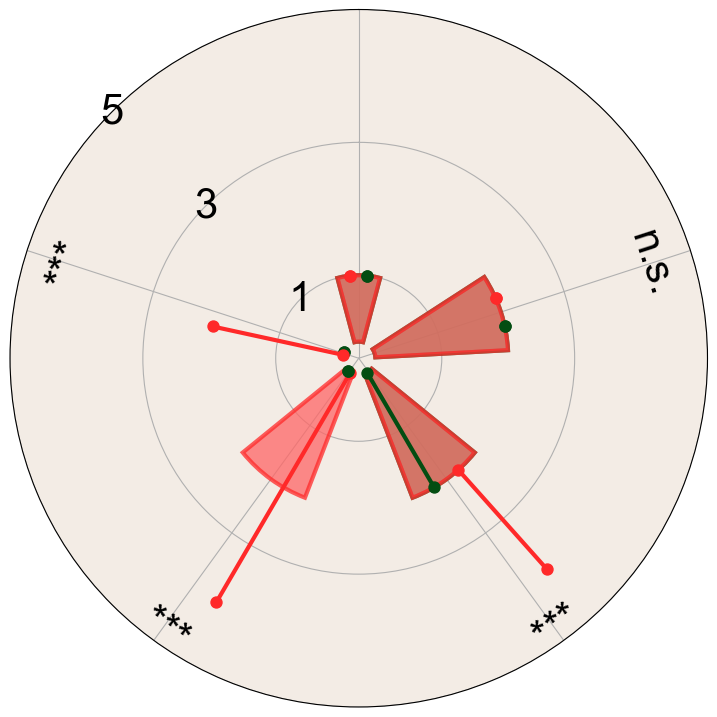

In [5]:
'''
1D feature distribution
'''

feat_list = [f'L{x} Branch Num' for x in range(1,6)]


ANGLES = np.linspace(2 * np.pi, 0, len(feat_list), endpoint=False)
print(ANGLES)

for thres in [50,]:

    tmpdf1 = dict_df_morpho_mouse[thres].loc[df_ct_mouse.index][feat_list]
    tmpdf2 = dict_df_morpho_human[thres].loc[df_ct_human.index[df_ct_human['homologous'].isin(homo_color_lut)]][feat_list]
    tmpdf1 = tmpdf1.dropna()
    tmpdf2 = tmpdf2.dropna()
    
    group1_meta = pd.DataFrame(index=tmpdf1.index)
    group2_meta = pd.DataFrame(index=tmpdf2.index)
    
    group1_meta['brain_region'] = df_ct_mouse.loc[tmpdf1.index, "CellType"]
    group1_meta['subject'] = "no_donor"
    
    group2_meta['brain_region'] = df_ct_human.loc[tmpdf2.index, "CellType"]
    group2_meta['subject'] = df_ct_human.loc[tmpdf2.index, "Patient_Num"]
    
    
    bst = [bootstrap_stat_test(tmpdf1.values[:,x],tmpdf2.values[:,x],stat='mwu',
                               group1_meta=group1_meta, group2_meta=group2_meta) for x in range(0 if den_type=='basal' else 1, tmpdf1.shape[1])]
    if len(bst)!=len(feat_list):
        bst = [(None,None,None,None)]+bst
    print(bst)
    
    perc_tmpdf1 = np.percentile(tmpdf1.values,[25,50,75],axis=0,)
    perc_tmpdf2 = np.percentile(tmpdf2.values,[25,50,75],axis=0,)
    bias=0.1

    fig, ax = plt.subplots(figsize=(9, 12.6), subplot_kw={"projection": "polar"})
    
    fig.patch.set_facecolor("white")
    ax.set_facecolor(np.sqrt(np.array([231,218,205])/255.0))
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_ylim(-1/4, 5) # apical 5 basal 15 all 20
    # ax.set_ylim(-1*400/25,400)
    # ax.set_ylim(-(1.1e+6)/25,1.1e+6)
    
    for i in range(len(ANGLES)):
        if perc_tmpdf2[1][i]>perc_tmpdf1[1][i]:
            ax.bar(ANGLES[i], perc_tmpdf2[1][i], color=color2, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color2))
            ax.bar(ANGLES[i], perc_tmpdf1[1][i], color=color1, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color1))
            
            ax.vlines(ANGLES[i]+bias, perc_tmpdf2[0][i], perc_tmpdf2[2][i], color=np.square(color2), ls='-', zorder=11,lw=3)
            ax.scatter(ANGLES[i]+bias, perc_tmpdf2[0][i], s=250, marker='.', color=np.square(color2), zorder=11)
            ax.scatter(ANGLES[i]+bias, perc_tmpdf2[2][i], s=250, marker='.', color=np.square(color2), zorder=11)
            
            ax.vlines(ANGLES[i]-bias, perc_tmpdf1[0][i], perc_tmpdf1[2][i], color=np.square(color1), ls='-', zorder=11, lw=3)
            ax.scatter(ANGLES[i]-bias, perc_tmpdf1[0][i], s=250, marker='.', color=np.square(color1), zorder=11)
            ax.scatter(ANGLES[i]-bias, perc_tmpdf1[2][i], s=250, marker='.', color=np.square(color1), zorder=11)
        else:
            ax.bar(ANGLES[i], perc_tmpdf1[1][i], color=color1, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color1))
            ax.bar(ANGLES[i], perc_tmpdf2[1][i], color=color2, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color2))
    
            ax.vlines(ANGLES[i]-bias, perc_tmpdf1[0][i], perc_tmpdf1[2][i], color=np.square(color1), ls='-', zorder=11, lw=3)
            ax.scatter(ANGLES[i]-bias, perc_tmpdf1[0][i], s=250, marker='.', color=np.square(color1), zorder=11)
            ax.scatter(ANGLES[i]-bias, perc_tmpdf1[2][i], s=250, marker='.', color=np.square(color1), zorder=11)
            
            ax.vlines(ANGLES[i]+bias, perc_tmpdf2[0][i], perc_tmpdf2[2][i], color=np.square(color2), ls='-', zorder=11,lw=3)
            ax.scatter(ANGLES[i]+bias, perc_tmpdf2[0][i], s=250, marker='.', color=np.square(color2), zorder=11)
            ax.scatter(ANGLES[i]+bias, perc_tmpdf2[2][i], s=250, marker='.', color=np.square(color2), zorder=11)
        ax.text(ANGLES[i],0.875*5,bst[i][1],rotation=-72*i, ha='center',va='center',fontsize=30)
    
    # # Set the labels
    ax.set_xticks(ANGLES)
    ax.set_xticklabels(feat_list, size=5)
    ax.set_xticklabels([])
    # ax.set_rgrids([5,10,15],angle=45,fontsize=30,verticalalignment='center',horizontalalignment='center')  # 50
    ax.set_rgrids([1,3,5],angle=45,fontsize=30,verticalalignment='center',horizontalalignment='center')  # 50 apical
    # ax.set_rgrids([100,200,300,400,],angle=55,fontsize=20,zorder=20,verticalalignment='center',horizontalalignment='center')  # 50
    
    # plt.close()
    # plt.clf()
 

In [6]:
df_sourcedata = pd.DataFrame(columns=['L1 Branch Num', 'L2 Branch Num','L3 Branch Num',
                                      'L4 Branch Num','L5 Branch Num', 'species'])
df_sourcedata = pd.concat([df_sourcedata, pd.concat([tmpdf1, 
                                                     pd.Series(['mouse']*tmpdf1.shape[0], index=tmpdf1.index, name='species'),
                                                     df_ct_mouse.loc[tmpdf1.index, 'homologous']], axis=1)], axis=0)
df_sourcedata = pd.concat([df_sourcedata, pd.concat([tmpdf2, 
                                                     pd.Series(['human']*tmpdf2.shape[0], index=tmpdf2.index, name='species'),
                                                     df_ct_human.loc[tmpdf2.index, 'homologous']], axis=1)], axis=0)
# df_sourcedata.to_csv(rf'..\Tables\source_data\Fig_5AB_{den_type}_radar{"_pyr23" if pyr23_only else ""}.csv',index=False)

[6.28318531 5.02654825 3.76991118 2.51327412 1.25663706]
0.9999998060972887
4.020856103477415e-29
1.5955590683555675e-14
0.9999996568273505
[(None, None, None, None), (0.00018765360592565806, 'n.s.', -0.44107945668645776, 0.9999998060972887), (5.859937800899002e-11, '***', -0.9005463231991911, 4.020856103477415e-29), (4.483306483057722e-11, '***', -0.9327631381975041, 1.5955590683555675e-14), (1.1140524758363827e-06, 'n.s.', -0.6574077598230892, 0.9999996568273505)]
1.351705241429061e-05
0.9999999935113838
0.9999999009928711
0.9999999652521971
[(None, None, None, None), (0.0030518554341101263, '***', -0.48360081985416226, 1.351705241429061e-05), (3.9993881207296675e-06, 'n.s.', -1.040757110227867, 0.9999999935113838), (6.958953212714843e-08, 'n.s.', -1.2789140992942092, 0.9999999009928711), (0.00026639179345650974, 'n.s.', -0.9381052952149086, 0.9999999652521971)]
bfgs not converged, try powell
nan
6.090602682816039e-18
1.3140338126111015e-30
bfgs not converged, try powell
nan
[(None, 

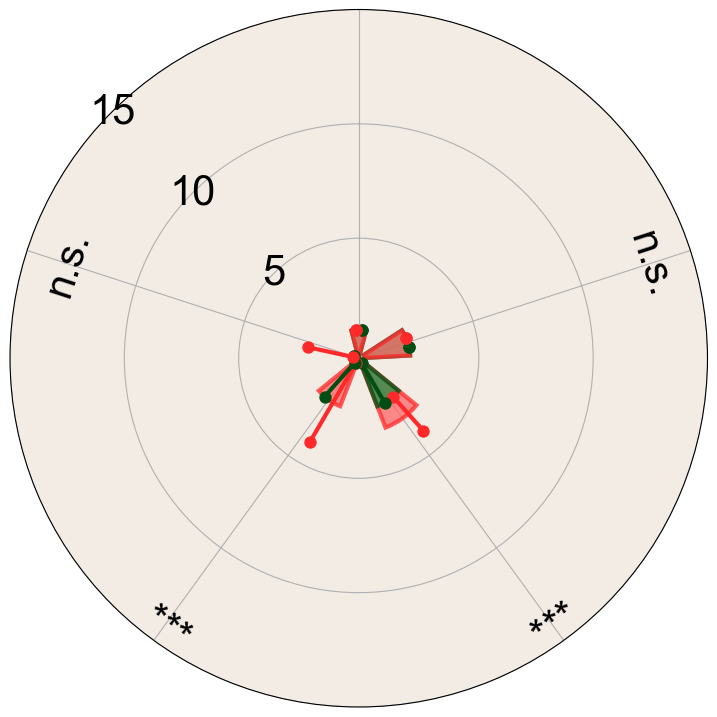

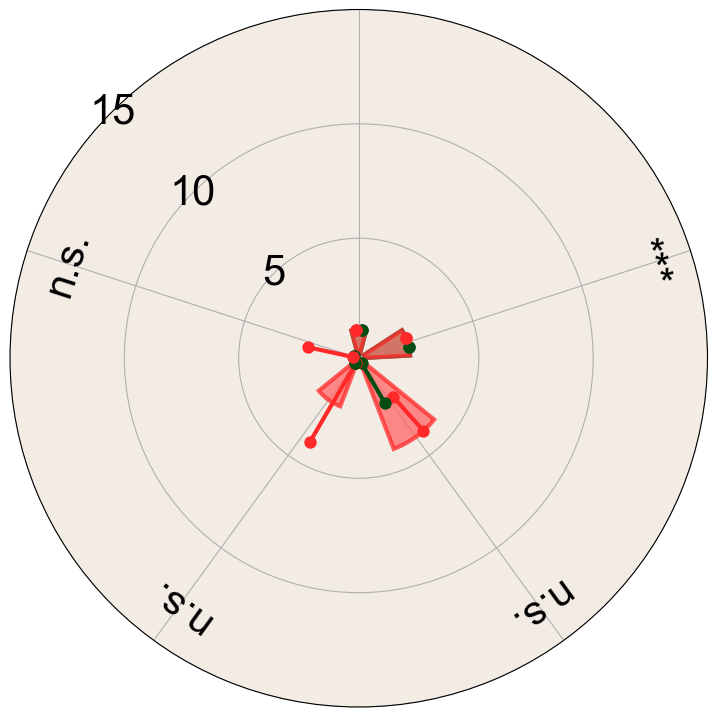

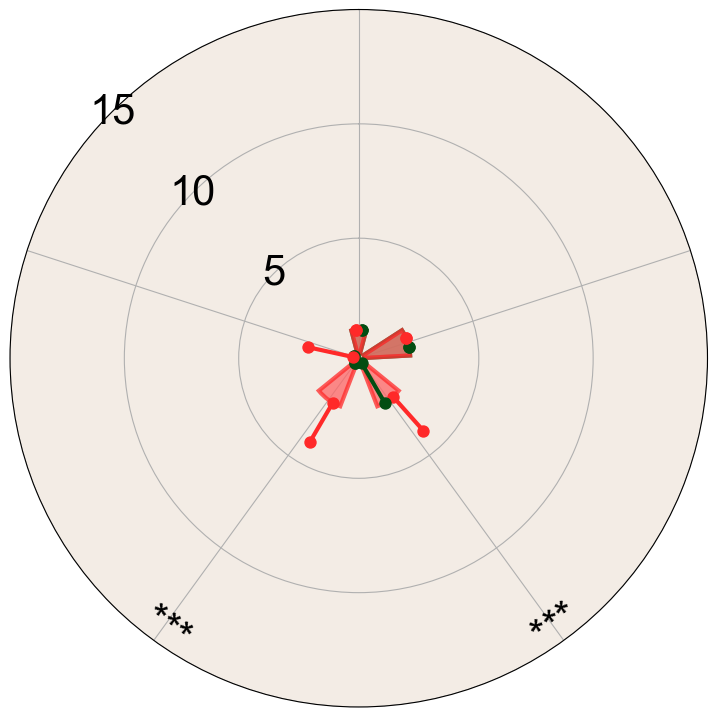

In [7]:
'''
1D feature distribution
'''

feat_list = [f'L{x} Branch Num' for x in range(1,6)]


ANGLES = np.linspace(2 * np.pi, 0, len(feat_list), endpoint=False)
print(ANGLES)

for thres in [50,]:
    for homo_ct in homo_color_lut:
        
        tmpdf1 = dict_df_morpho_mouse[thres].loc[df_ct_mouse.index[df_ct_mouse['homologous']==homo_ct]][feat_list]
        tmpdf2 = dict_df_morpho_human[thres].loc[df_ct_human.index[df_ct_human['homologous']==homo_ct]][feat_list]
        
        tmpdf1 = tmpdf1.dropna()
        tmpdf2 = tmpdf2.dropna()
        
        group1_meta = pd.DataFrame(index=tmpdf1.index)
        group2_meta = pd.DataFrame(index=tmpdf2.index)
        
        group1_meta['brain_region'] = df_ct_mouse.loc[tmpdf1.index, "CellType"]
        group1_meta['subject'] = "no_donor"
        
        group2_meta['brain_region'] = df_ct_human.loc[tmpdf2.index, "CellType"]
        group2_meta['subject'] = df_ct_human.loc[tmpdf2.index, "Patient_Num"]
        
        
        bst = [bootstrap_stat_test(tmpdf1.values[:,x],tmpdf2.values[:,x],stat='mwu',
                                group1_meta=group1_meta, group2_meta=group2_meta) for x in range(0 if den_type=='basal' else 1, tmpdf1.shape[1])]
        if len(bst)!=len(feat_list):
            bst = [(None,None,None,None)]+bst
        print(bst)
        
        perc_tmpdf1 = np.percentile(tmpdf1.values,[25,50,75],axis=0,)
        perc_tmpdf2 = np.percentile(tmpdf2.values,[25,50,75],axis=0,)
        bias=0.1

        fig, ax = plt.subplots(figsize=(9, 12.6), subplot_kw={"projection": "polar"})
        
        fig.patch.set_facecolor("white")
        ax.set_facecolor(np.sqrt(np.array([231,218,205])/255.0))
        
        ax.set_theta_offset(np.pi / 2)
        ax.set_ylim(-1/4, 15)
        # ax.set_ylim(-1*400/25,400)
        # ax.set_ylim(-(1.1e+6)/25,1.1e+6)
        
        for i in range(len(ANGLES)):
            if perc_tmpdf2[1][i]>perc_tmpdf1[1][i]:
                ax.bar(ANGLES[i], perc_tmpdf2[1][i], color=color2, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color2))
                ax.bar(ANGLES[i], perc_tmpdf1[1][i], color=color1, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color1))
                
                ax.vlines(ANGLES[i]+bias, perc_tmpdf2[0][i], perc_tmpdf2[2][i], color=np.square(color2), ls='-', zorder=11,lw=3)
                ax.scatter(ANGLES[i]+bias, perc_tmpdf2[0][i], s=250, marker='.', color=np.square(color2), zorder=11)
                ax.scatter(ANGLES[i]+bias, perc_tmpdf2[2][i], s=250, marker='.', color=np.square(color2), zorder=11)
                
                ax.vlines(ANGLES[i]-bias, perc_tmpdf1[0][i], perc_tmpdf1[2][i], color=np.square(color1), ls='-', zorder=11, lw=3)
                ax.scatter(ANGLES[i]-bias, perc_tmpdf1[0][i], s=250, marker='.', color=np.square(color1), zorder=11)
                ax.scatter(ANGLES[i]-bias, perc_tmpdf1[2][i], s=250, marker='.', color=np.square(color1), zorder=11)
            else:
                ax.bar(ANGLES[i], perc_tmpdf1[1][i], color=color1, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color1))
                ax.bar(ANGLES[i], perc_tmpdf2[1][i], color=color2, alpha=0.75, width=0.52, zorder=10, lw=3, edgecolor=np.square(color2))
        
                ax.vlines(ANGLES[i]-bias, perc_tmpdf1[0][i], perc_tmpdf1[2][i], color=np.square(color1), ls='-', zorder=11, lw=3)
                ax.scatter(ANGLES[i]-bias, perc_tmpdf1[0][i], s=250, marker='.', color=np.square(color1), zorder=11)
                ax.scatter(ANGLES[i]-bias, perc_tmpdf1[2][i], s=250, marker='.', color=np.square(color1), zorder=11)
                
                ax.vlines(ANGLES[i]+bias, perc_tmpdf2[0][i], perc_tmpdf2[2][i], color=np.square(color2), ls='-', zorder=11,lw=3)
                ax.scatter(ANGLES[i]+bias, perc_tmpdf2[0][i], s=250, marker='.', color=np.square(color2), zorder=11)
                ax.scatter(ANGLES[i]+bias, perc_tmpdf2[2][i], s=250, marker='.', color=np.square(color2), zorder=11)
            ax.text(ANGLES[i],15*0.875,bst[i][1],rotation=-72*i, ha='center',va='center',fontsize=30)
           
        # # Set the labels
        
        ax.set_xticks(ANGLES)
        # ax.set_xticklabels(feat_list, size=5)
        ax.set_xticklabels([])
        ax.set_rgrids([5,10,15],angle=45,fontsize=30,verticalalignment='center',horizontalalignment='center')  # 50
        # ax.set_rgrids([1,3,5],angle=45,fontsize=30,verticalalignment='center',horizontalalignment='center')  # 50 apical
        # ax.set_rgrids([100,200,300,400,],angle=55,fontsize=20,zorder=20,verticalalignment='center',horizontalalignment='center')  # 50
        # plt.close()
        # plt.clf()



[6.28318531 5.49778714 4.71238898 3.92699082 3.14159265 2.35619449
 1.57079633 0.78539816]


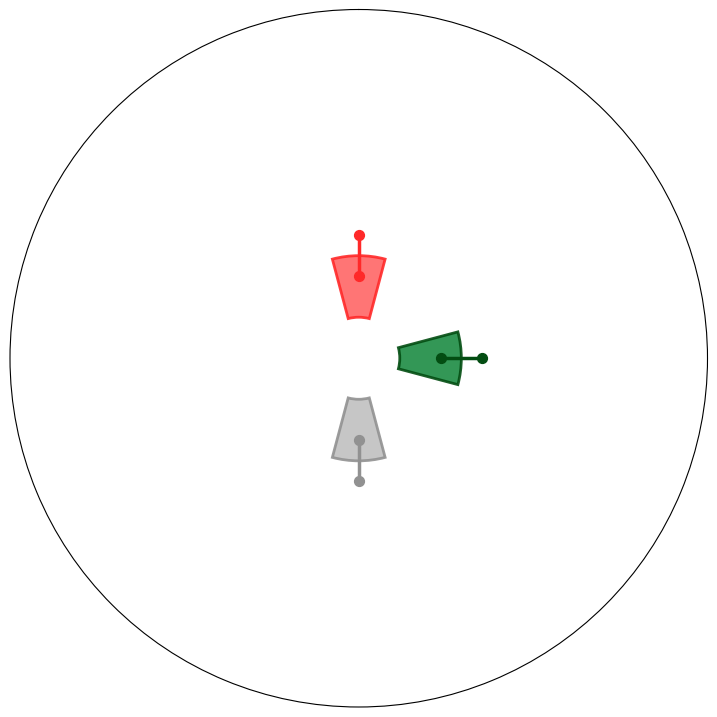

In [ ]:
'''
radar chart legend
'''

feat_list = [f'L{x} Branch Num' for x in range(1,9)]

ANGLES = np.linspace(2 * np.pi, 0, len(feat_list), endpoint=False)
print(ANGLES)

# Some layout stuff ----------------------------------------------
# Initialize layout in polar coordinates
fig, ax = plt.subplots(figsize=(9, 12.6), subplot_kw={"projection": "polar"})

# Set background color to white, both axis and figure.
fig.patch.set_facecolor("white")
ax.set_facecolor('white')

# ax.set_theta_offset(1.2 * np.pi / 2)
ax.set_theta_offset(np.pi / 2)
ax.set_ylim(-2, 15)

bias=0.0

i=0
ax.bar(ANGLES[i], 3, color=color2, alpha=0.9, width=0.52, zorder=10, lw=2, edgecolor=np.square(color2))
ax.vlines(ANGLES[i]+bias, 2, 4, color=np.square(color2), ls='-', zorder=11,lw=2.5)
ax.scatter(ANGLES[i]+bias, 2, s=200, marker='.', color=np.square(color2), zorder=11)
ax.scatter(ANGLES[i]+bias, 4, s=200, marker='.', color=np.square(color2), zorder=11)

ax.bar(ANGLES[i+2], 3, color=color1, alpha=0.9, width=0.52, zorder=10, lw=2, edgecolor=np.square(color1))
ax.vlines(ANGLES[i+2]+bias, 2, 4, color=np.square(color1), ls='-', zorder=11,lw=2.5)
ax.scatter(ANGLES[i+2]+bias, 2, s=200, marker='.', color=np.square(color1), zorder=11)
ax.scatter(ANGLES[i+2]+bias, 4, s=200, marker='.', color=np.square(color1), zorder=11)

tmpc = np.array([192,192,192])/255.0
ax.bar(ANGLES[i+2+2], 3, color=tmpc, alpha=0.9, width=0.52, zorder=10, lw=2, edgecolor=np.square(tmpc))
ax.vlines(ANGLES[i+2+2]+bias, 2, 4, color=np.square(tmpc), ls='-', zorder=11,lw=2.5)
ax.scatter(ANGLES[i+2+2]+bias, 2, s=200, marker='.', color=np.square(tmpc), zorder=11)
ax.scatter(ANGLES[i+2+2]+bias, 4, s=200, marker='.', color=np.square(tmpc), zorder=11)


ax.set_xticks(ANGLES)
# ax.set_xticklabels(feat_list, size=5)
ax.set_xticklabels([])
ax.set_rgrids([],angle=45,fontsize=15)
ax.set_thetagrids([],angle=45,fontsize=15)
ax.grid('off')


In [8]:
'''Comparison of the difference between regions'''
select_cropthres = [50]
df_morpho_mouse = pd.DataFrame()
df_morpho_human = pd.DataFrame()
for crop_thres in select_cropthres:
    tmpdf = dict_df_morpho_mouse[crop_thres].copy()
    tmpdf.columns = [f"R{crop_thres}_"+x for x in tmpdf.columns]
    df_morpho_mouse = pd.concat([df_morpho_mouse, tmpdf], axis=1)
    
    tmpdf = dict_df_morpho_human[crop_thres].copy()
    tmpdf.columns = [f"R{crop_thres}_"+x for x in tmpdf.columns]
    df_morpho_human = pd.concat([df_morpho_human, tmpdf], axis=1)
    
    
df_morpho_mouse.dropna(how='any', axis=0, inplace=True)
df_morpho_human.dropna(how='any', axis=0, inplace=True)

print(df_morpho_mouse.shape)

(6606, 12)


In [10]:
def compute_histograms(arr1,arr2,outlier: str='minmax'):
    arr1 = np.array(arr1)
    arr2 = np.array(arr2)

    if outlier not in ['minmax','boxplot']:
        raise ValueError(f'invalid outlier value: {outlier}')
    
    lowb, highb = 0, 0
    
    if outlier=='boxplot':
        Q11,Q12,Q13=np.percentile(arr1, [25,50,75])
        IQR1 = Q13-Q11
        lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
        Q21,Q22,Q23=np.percentile(arr2, [25,50,75])
        IQR2 = Q23-Q21
        lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
        lowb = min(lowb1, lowb2)
        highb = max(highb1, highb2)
    elif outlier=='minmax':
        lowb = min(np.min(arr1),np.min(arr2))
        highb = max(np.max(arr1),np.max(arr2))
        
    arr1_filter = arr1[(arr1>=lowb)&(arr1<=highb)]
    arr2_filter = arr2[(arr2>=lowb)&(arr2<=highb)]
    arr_concat = np.hstack([arr1_filter,arr2_filter])
    ct_arr_concat = [0]*len(arr1_filter)+[1]*len(arr2_filter)
    
    _, bin_edges = np.histogram(arr_concat,bins='auto')
    bin_num = len(bin_edges) - 1
    interval = bin_edges[1]-bin_edges[0]
    
    bin_lowb = np.min(bin_edges)
    bin_highb = np.max(bin_edges)

    hist_fv=[]
    for i,v in enumerate(arr_concat):
        if v<bin_lowb:
            # hist_fv.append(0)
            # print(v,bin_lowb)
            continue
        elif v>bin_highb:
            # hist_fv.append(bin_num-1)
            # print(v,bin_highb)
            continue
        elif v==bin_highb:
            hist_fv.append((v-bin_lowb)//interval-1)
        else:
            hist_fv.append((v-bin_lowb)//interval)
            
    return hist_fv[:len(arr1_filter)], hist_fv[len(arr1_filter):]
    

def DIFF_feat_ct(arr1,arr2,method='JSD',stat_test=True,group1_meta=None,group2_meta=None):
    assert method in ['NMI','JSD','MI','AMI','CORR'], f'unsupported method: {method}'
    def JSD_score(p,q):
        M=(p+q)/2
        output = 0.5*scipy.stats.entropy(p,M,base=2)+0.5*scipy.stats.entropy(q, M,base=2)
        if np.isnan(output):
            return 0.0
        else:
            return output

    
    Q11,Q12,Q13=np.percentile(arr1, [25,50,75])
    IQR1 = Q13-Q11
    lowb1,highb1 = Q11-1.5*IQR1, Q13+1.5*IQR1
    Q21,Q22,Q23=np.percentile(arr2, [25,50,75])
    IQR2 = Q23-Q21
    lowb2,highb2 = Q21-1.5*IQR2, Q23+1.5*IQR2
    lowb = min(lowb1, lowb2)
    highb = max(highb1, highb2)

    
    # arr_concat = np.hstack((arr1[(arr1>=lowb)&(arr1<highb)],arr2[(arr2>=lowb)&(arr2<highb)]))
    # ct_arr = [0]*len(arr1[(arr1>=lowb)&(arr1<highb)])+[1]*len(arr2[(arr2>=lowb)&(arr2<highb)])

    arr_concat = np.hstack([arr1,arr2])
    ct_arr = [0]*len(arr1)+[1]*len(arr2)
    
    # _, bin_edges = np.histogram(arr_concat[(arr_concat>=lowb)&(arr_concat<=highb)],bins='auto')
    _, bin_edges = np.histogram(arr_concat,bins='auto')
    bin_num = len(bin_edges)-1
    interval = bin_edges[1]-bin_edges[0]
    tmparr1 = arr_concat[:len(arr1)]
    tmparr2 = arr_concat[len(arr1):]
    if stat_test:
        pv,sig,cohens_d,pv_mlm = bootstrap_stat_test(arr1,arr2,'mwu',group1_meta=group1_meta,group2_meta=group2_meta)
    else:
        pv,sig,cohens_d,pv_mlm = None, None,None, None
    
    bin_lowb = np.min(bin_edges)
    bin_highb = np.max(bin_edges)

    if method in ['NMI','MI','AMI','CORR']:
        hist_fv=[]
        for i,v in enumerate(arr_concat):
            if v<bin_lowb:
                # hist_fv.append(0)
                # print(v,bin_lowb)
                continue
            elif v>bin_highb:
                # hist_fv.append(bin_num-1)
                # print(v,bin_highb)
                continue
            elif v==bin_highb:
                hist_fv.append((v-bin_lowb)//interval-1)
            else:
                hist_fv.append((v-bin_lowb)//interval)
        if method=='NMI':
            score = normalized_mutual_info_score(hist_fv,ct_arr)
        elif method=='MI':
            score = mutual_info_score(hist_fv,ct_arr)
        elif method=='AMI':
            score = adjusted_mutual_info_score(hist_fv,ct_arr)
        elif method=='CORR':
            score = abs(scipy.stats.pointbiserialr(hist_fv,ct_arr).correlation)
        
    elif method == 'JSD':
        hist_fv1 = np.zeros(bin_num)
        hist_fv2 = np.zeros(bin_num)

        for i,v in enumerate(tmparr1):
            if v<bin_lowb:
                # hist_fv1.append(0)
                continue
            elif v>bin_highb:
                # hist_fv1.append(bin_num-1)
                continue
            elif v==bin_highb:
                hist_fv1[int((v-bin_lowb)//interval-1)]+=1
            else:
                hist_fv1[int((v-bin_lowb)//interval)]+=1
        for i,v in enumerate(tmparr2):
            if v<bin_lowb:
                # hist_fv2.append(0)
                continue
            elif v>bin_highb:
                # hist_fv2.append(bin_num-1)
                continue
            elif v==bin_highb:
                hist_fv2[int((v-bin_lowb)//interval-1)]+=1
            else:
                hist_fv2[int((v-bin_lowb)//interval)]+=1
        hist_fv1 = np.asarray(hist_fv1)/(np.sum(hist_fv1)+1e-10)
        hist_fv2 = np.asarray(hist_fv2)/(np.sum(hist_fv2)+1e-10)
        score = JSD_score(hist_fv1,hist_fv2)
    return score,pv,sig,cohens_d,pv_mlm


1.3996596405045918e-107


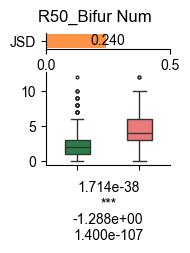

9.732718405074295e-12


<Figure size 640x480 with 0 Axes>

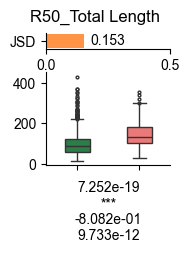

<Figure size 640x480 with 0 Axes>

In [11]:
'''
all feature boxplot mouse vs human
'''
# feature_score = []
for f_i,feat in enumerate(['R50_'+x for x in mapped_cols]):
    tmp_f_s = []

    fig,axs = plt.subplots(2,1,figsize=(2,2.7),height_ratios=[1,6])
    
    # preparation for data
    tmpindice = df_morpho_mouse.index
    tmpindice = np.intersect1d(tmpindice, df_ct_mouse[df_ct_mouse['homologous'].isin(homo_color_lut.keys())].index)
    df_morpho_mouse_homo = df_morpho_mouse.loc[tmpindice]
    
    tmpindice = df_morpho_human.index
    tmpindice = np.intersect1d(tmpindice, df_ct_human[df_ct_human['homologous'].isin(homo_color_lut.keys())].index)
    df_morpho_human_homo = df_morpho_human.loc[tmpindice]

    # standardization
    arr_morpho = np.vstack([df_morpho_mouse_homo.values,df_morpho_human_homo.values])
    stand_mean = arr_morpho.mean(axis=0)
    stand_std = arr_morpho.std(axis=0)
    arr_morpho_stand = (arr_morpho - stand_mean) / stand_std
    
    df_morpho_mouse_homo_stand = (df_morpho_mouse_homo - stand_mean) / stand_std
    df_morpho_human_homo_stand = (df_morpho_human_homo - stand_mean) / stand_std
    
    
    group1_meta = pd.DataFrame(index=df_morpho_mouse_homo.index)
    group2_meta = pd.DataFrame(index=df_morpho_human_homo.index)
    
    group1_meta['brain_region'] = df_ct_mouse.loc[df_morpho_mouse_homo.index, "CellType"]
    group1_meta['subject'] = "no_donor"
    
    group2_meta['brain_region'] = df_ct_human.loc[df_morpho_human_homo.index, "CellType"]
    group2_meta['subject'] = df_ct_human.loc[df_morpho_human_homo.index, "Patient_Num"]
        

    score,_1,_2,_3,_4 = DIFF_feat_ct(df_morpho_mouse_homo_stand[feat].values,
                               df_morpho_human_homo_stand[feat].values,method='JSD',
                               group1_meta=group1_meta,group2_meta=group2_meta)
    tmp_f_s.append(score)

    # boxplot
    ax = axs[1]

    sns.boxplot(data=[df_morpho_mouse_homo[feat].values, df_morpho_human_homo[feat].values],
                ax=ax, palette=[color1, color2], width=0.4, fliersize=2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels([])
    ax.set_xlabel(f'{_1:.3e}\n{_2}\n{_3:.3e}\n{_4:.3e}')

    # JSD bar
    ax = axs[0]
    ax.barh(0,score,color='#FF6F08',alpha=0.75)
    ax.text(x=0.25,y=0,s=f'{score:.3f}',horizontalalignment='center',verticalalignment='center')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0,0.5)
    ax.set_xticks([0,0.5])
    ax.set_yticks([0])
    ax.set_yticklabels(['JSD'])
    # ax.set_title(homo_ct)
        
    fig.suptitle(feat,va='top',y=0.92)
    fig.tight_layout(h_pad=0)
    plt.show()
    plt.close()
    plt.clf()
        

In [12]:
df_sourcedata = pd.DataFrame()
df_sourcedata = pd.concat([df_sourcedata, pd.concat([df_morpho_mouse_homo[[f"R50_{x}" for x in mapped_cols]], 
                           pd.Series(['mouse']*len(df_morpho_mouse_homo), index=df_morpho_mouse_homo.index, name='species'), 
                           df_ct_mouse.loc[df_morpho_mouse_homo.index, 'homologous']], axis=1)])
df_sourcedata = pd.concat([df_sourcedata, pd.concat([df_morpho_human_homo[[f"R50_{x}" for x in mapped_cols]], 
                           pd.Series(['human']*len(df_morpho_human_homo), index=df_morpho_human_homo.index, name='species'), 
                           df_ct_human.loc[df_morpho_human_homo.index, 'homologous']], axis=1)])
# df_sourcedata.to_csv(rf'..\Tables\source_data\Fig_5AB_{den_type}_boxplot{"_pyr23" if pyr23_only else ""}.csv',index=False)

0.9999995895077446
0.999999922815467
1.4005314964348187e-35


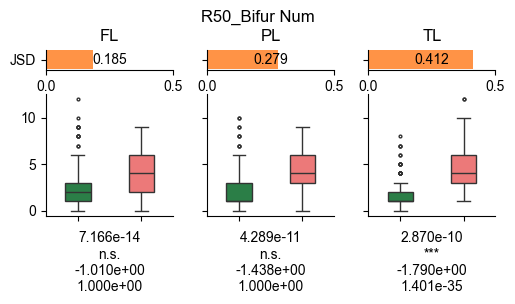

7.892654867296375e-10
1.1550802207167102e-20
3.1793190649500177e-19


<Figure size 640x480 with 0 Axes>

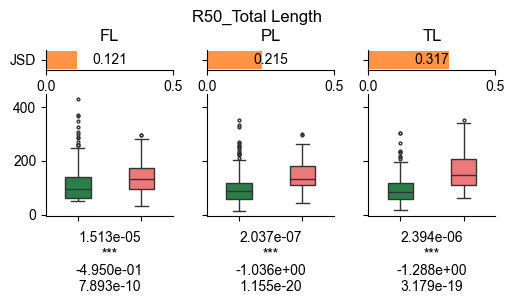

<Figure size 640x480 with 0 Axes>

In [13]:
'''
all feature boxplot 3 in 1
'''
feature_score = []
for f_i,feat in enumerate(['R50_'+x for x in mapped_cols]):
    tmp_f_s = []

    fig,axs = plt.subplots(2,3,figsize=(5.25,3.25),height_ratios=[1,6],
                           sharey='row',
                           # sharey=None,
                          )
    
    for ct_i,homo_ct in enumerate(homo_color_lut.keys()):
        # print(homo_ct)
        # preparation for data
        tmpindice = df_morpho_mouse.index
        tmpindice = np.intersect1d(tmpindice, df_ct_mouse[df_ct_mouse['homologous']==homo_ct].index)
        df_morpho_mouse_homo = df_morpho_mouse.loc[tmpindice]
        
        tmpindice = df_morpho_human.index
        tmpindice = np.intersect1d(tmpindice, df_ct_human[df_ct_human['homologous']==homo_ct].index)
        df_morpho_human_homo = df_morpho_human.loc[tmpindice]
    
        # standardization
        arr_morpho = np.vstack([df_morpho_mouse_homo.values,df_morpho_human_homo.values])
        stand_mean = arr_morpho.mean(axis=0)
        stand_std = arr_morpho.std(axis=0)
        arr_morpho_stand = (arr_morpho - stand_mean) / stand_std
        
        df_morpho_mouse_homo_stand = (df_morpho_mouse_homo - stand_mean) / stand_std
        df_morpho_human_homo_stand = (df_morpho_human_homo - stand_mean) / stand_std

        group1_meta = pd.DataFrame(index=df_morpho_mouse_homo.index)
        group2_meta = pd.DataFrame(index=df_morpho_human_homo.index)
        
        group1_meta['brain_region'] = df_ct_mouse.loc[df_morpho_mouse_homo.index, "CellType"]
        group1_meta['subject'] = "no_donor"
        
        group2_meta['brain_region'] = df_ct_human.loc[df_morpho_human_homo.index, "CellType"]
        group2_meta['subject'] = df_ct_human.loc[df_morpho_human_homo.index, "Patient_Num"]
            

        score,_1,_2,_3,_4 = DIFF_feat_ct(df_morpho_mouse_homo_stand[feat].values,
                                df_morpho_human_homo_stand[feat].values,method='JSD',
                                group1_meta=group1_meta,group2_meta=group2_meta)        
        tmp_f_s.append(score)

        # boxplot
        ax = axs[1,ct_i]
        sns.boxplot(data=[df_morpho_mouse_homo[feat].values, df_morpho_human_homo[feat].values],
                ax=ax, palette=[color1, color2], width=0.4, fliersize=2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xticklabels([])
        ax.set_xlabel(f'{_1:.3e}\n{_2}\n{_3:.3e}\n{_4:.3e}')
        # ax.set_title(f'{score:.2f}')
        
        # JSD bar
        ax = axs[0,ct_i]
        ax.barh(0,score,color='#FF6F08',alpha=0.75)
        ax.text(x=0.25,y=0,s=f'{score:.3f}',horizontalalignment='center',verticalalignment='center')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_xlim(0,0.5)
        ax.set_xticks([0,0.5])
        ax.set_yticks([0])
        ax.set_yticklabels(['JSD'])
        ax.set_title(homo_ct)
        
    fig.suptitle(feat,va='top',y=0.92)
    fig.tight_layout(h_pad=0)
    plt.show()
    plt.close()
    plt.clf()
        